In [1]:
import pandas as pd
import matplotlib.pyplot as plt

colunas = [
    "timestamp",
    "solucao",
    "caso",
    "execucao",
    "filosofo",
    "grau",
    "bebeu",
    "tempo_total_execucao",
    "tempo_tranquilo",
    "tempo_com_sede",
    "tempo_bebendo",
    "espera_media_sede",
    "tentativas_falhas",
]

df = pd.read_csv(
    "resultados/resultados_randomized_backoff.txt",
    sep=";",
    header=None,
    names=colunas
)

df.head()

,timestamp,solucao,caso,execucao,filosofo,grau,bebeu,tempo_total_execucao,tempo_tranquilo,tempo_com_sede,tempo_bebendo,espera_media_sede,tentativas_falhas
0,2026-05-11 20:34:10,Randomized Backoff,caso1,1,1,2,6,18.126054,5.838681,5.123661,6.002665,0.853943,22
1,2026-05-11 20:34:10,Randomized Backoff,caso1,1,2,2,6,18.126054,5.796410,6.241883,6.001520,1.040314,31
2,2026-05-11 20:34:10,Randomized Backoff,caso1,1,3,2,6,18.126054,6.783731,3.691368,6.000670,0.615228,20
3,2026-05-11 20:34:10,Randomized Backoff,caso1,1,4,2,6,18.126054,4.723185,3.867491,6.001101,0.644582,17
4,2026-05-11 20:34:10,Randomized Backoff,caso1,1,5,2,6,18.126054,7.100989,5.021150,6.002698,0.836858,23


In [2]:
df.groupby(["caso", "execucao", "filosofo"])["bebeu"].first().reset_index()

,caso,execucao,filosofo,bebeu
0,caso1,1,1,6
1,caso1,1,2,6
2,caso1,1,3,6
3,caso1,1,4,6
4,caso1,1,5,6
...,...,...,...,...
225,caso3,10,8,3
226,caso3,10,9,3
227,caso3,10,10,3
228,caso3,10,11,3


In [3]:
df_validacao = df.groupby(["caso", "execucao", "filosofo"])["bebeu"].first().reset_index()

df_validacao.groupby("caso")["bebeu"].describe()

,count,mean,std,min,25%,50%,75%,max
caso,,,,,,,,
caso1,50.0,6.0,0.0,6.0,6.0,6.0,6.0,6.0
caso2,60.0,6.0,0.0,6.0,6.0,6.0,6.0,6.0
caso3,120.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0


In [4]:
media_sede = (
    df.groupby(["caso", "filosofo"])["espera_media_sede"]
    .mean()
    .reset_index()
)

media_sede

,caso,filosofo,espera_media_sede
0,caso1,1,0.761202
1,caso1,2,0.827158
2,caso1,3,0.711690
3,caso1,4,0.899479
4,caso1,5,0.831721
5,caso2,1,0.548757
6,caso2,2,0.632959
7,caso2,3,0.654811
8,caso2,4,0.995830
9,caso2,5,0.372295


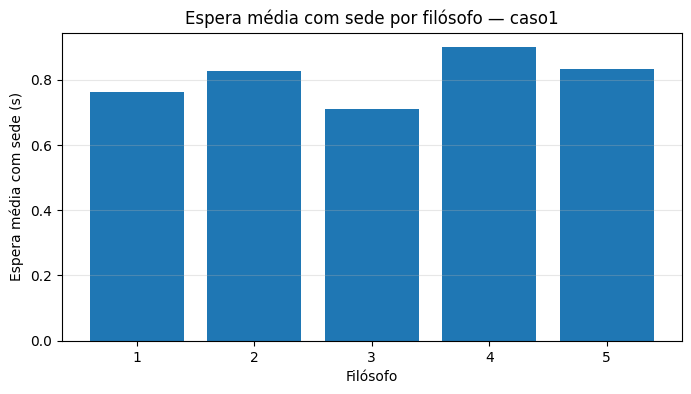

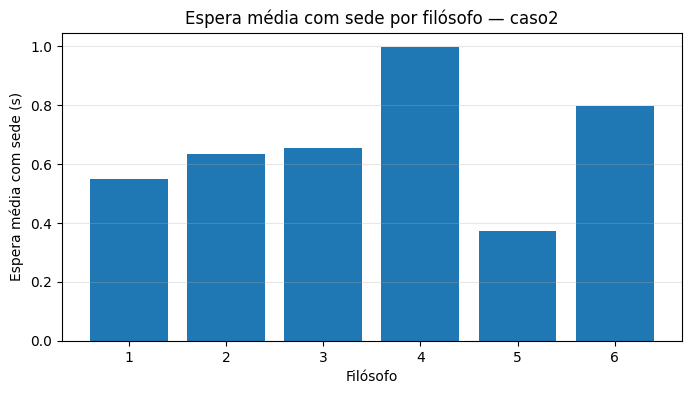

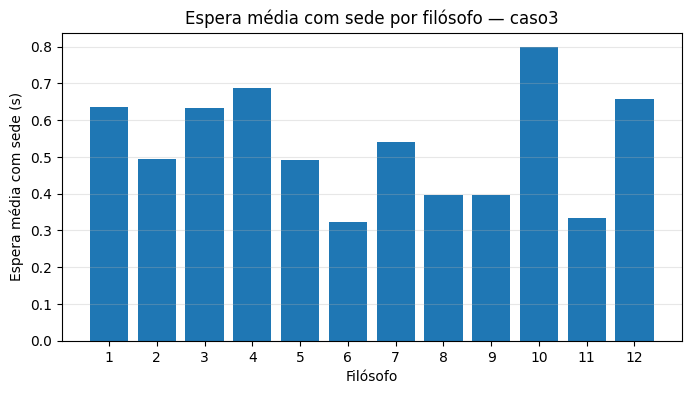

In [5]:
for caso in media_sede["caso"].unique():
    dados = media_sede[media_sede["caso"] == caso]

    plt.figure(figsize=(8, 4))
    plt.bar(dados["filosofo"], dados["espera_media_sede"])
    plt.xlabel("Filósofo")
    plt.ylabel("Espera média com sede (s)")
    plt.title(f"Espera média com sede por filósofo — {caso}")
    plt.xticks(dados["filosofo"])
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [6]:
tempo_total = (
    df.groupby(["caso", "execucao"])["tempo_total_execucao"]
    .first()
    .reset_index()
)

tempo_total.head()

,caso,execucao,tempo_total_execucao
0,caso1,1,18.126054
1,caso1,2,19.413042
2,caso1,3,19.377460
3,caso1,4,17.497518
4,caso1,5,17.793722


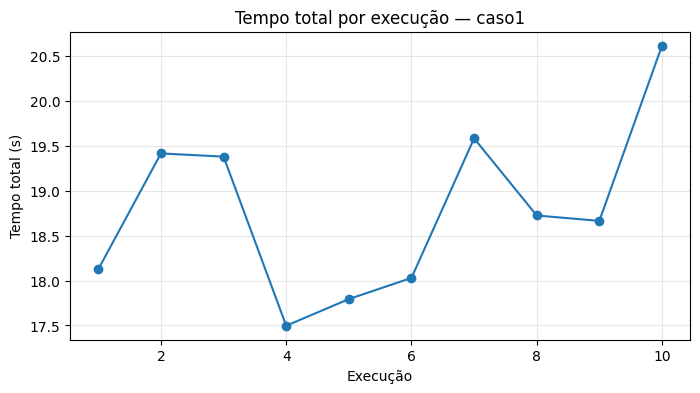

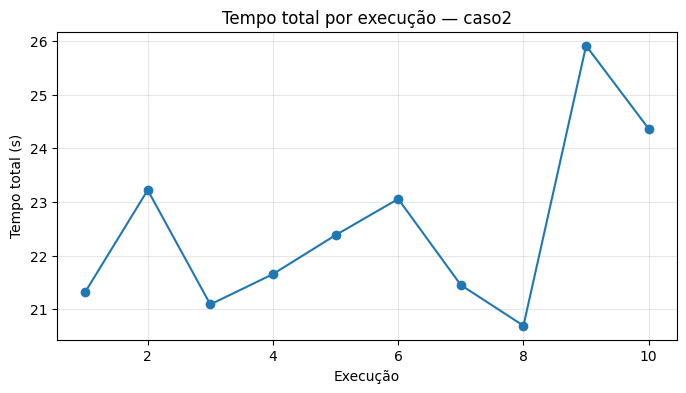

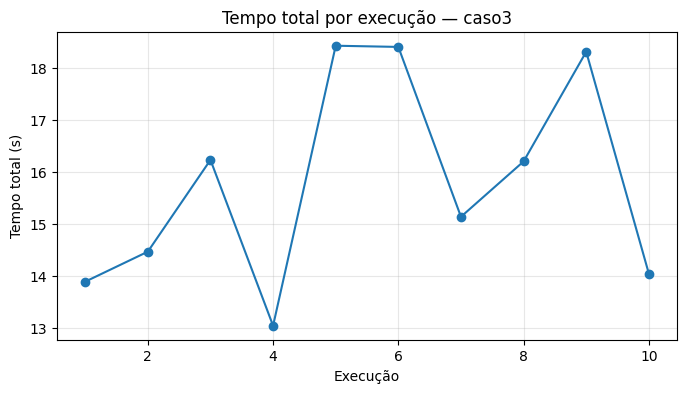

In [7]:
for caso in tempo_total["caso"].unique():
    dados = tempo_total[tempo_total["caso"] == caso]

    plt.figure(figsize=(8, 4))
    plt.plot(dados["execucao"], dados["tempo_total_execucao"], marker="o")
    plt.xlabel("Execução")
    plt.ylabel("Tempo total (s)")
    plt.title(f"Tempo total por execução — {caso}")
    plt.grid(alpha=0.3)
    plt.show()

In [8]:
resumo_casos = (
    tempo_total.groupby("caso")["tempo_total_execucao"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

resumo_casos

,caso,mean,std,min,max
0,caso1,18.781415,0.964705,17.497518,20.610639
1,caso2,22.512681,1.646330,20.692438,25.908711
2,caso3,15.819420,2.026669,13.043285,18.433657


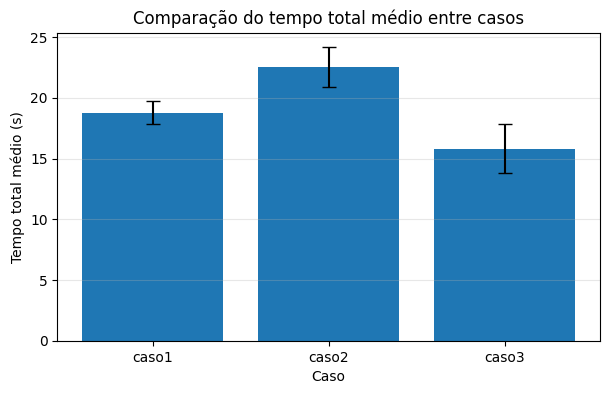

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(resumo_casos["caso"], resumo_casos["mean"], yerr=resumo_casos["std"], capsize=5)
plt.xlabel("Caso")
plt.ylabel("Tempo total médio (s)")
plt.title("Comparação do tempo total médio entre casos")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [10]:
starvation = (
    df.groupby(["caso", "execucao"])["espera_media_sede"]
    .agg(["min", "max", "mean", "std"])
    .reset_index()
)

starvation["razao_max_min"] = starvation["max"] / starvation["min"].replace(0, pd.NA)

starvation.head()

,caso,execucao,min,max,mean,std,razao_max_min
0,caso1,1,0.589100,1.108813,0.786521,0.177426,1.882216
1,caso1,2,0.282241,1.277703,0.824886,0.338195,4.526988
2,caso1,3,0.491055,1.154547,0.805482,0.253976,2.351156
3,caso1,4,0.363954,1.769794,0.836463,0.406583,4.862679
4,caso1,5,0.601215,1.628245,0.995634,0.309335,2.708258


In [11]:
resumo_starvation = (
    starvation.groupby("caso")["razao_max_min"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

resumo_starvation

,caso,mean,std,min,max
0,caso1,3.164422,1.040301,1.853123,4.862679
1,caso2,14385.693861,45455.077865,3.923121,143753.112470
2,caso3,239594.624458,93436.343106,118899.294032,373659.805007


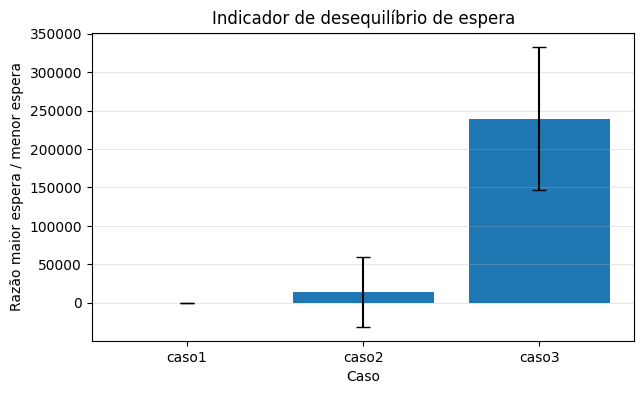

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(
    resumo_starvation["caso"],
    resumo_starvation["mean"],
    yerr=resumo_starvation["std"],
    capsize=5
)
plt.xlabel("Caso")
plt.ylabel("Razão maior espera / menor espera")
plt.title("Indicador de desequilíbrio de espera")
plt.grid(axis="y", alpha=0.3)
plt.show()